# The Tav-Hormone Story: Probability Density & Optimal Decisions

## 🧪 A story from the year 2036

Meet **Mr. Tavasoli**. It is the year 2036 and he has just discovered a new hormone —
the **tav-hormone** — that can be measured in the very early stages of pregnancy and is
correlated with the sex of the baby.

Some facts about Mr. Tavasoli's country (our **statistical population** / جامعه آماری):

- **70%** of newborns are **girls** → the *prior* probability $P(\text{girl}) = 0.7$
- **30%** of newborns are **boys** → the *prior* probability $P(\text{boy}) = 0.3$

The tav-hormone level is a **continuous** value. It is not a perfect test:
girls and boys both produce the hormone, but with **different distributions**.

Our question: *given a measured hormone level $x$, should we predict "girl" or "boy"?*

This is the essence of **classification** — and it leads us to one of the most
fundamental ideas in machine learning: the **Bayes optimal decision rule**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

## 📊 Modeling the hormone distributions

Let's assume (Mr. Tavasoli measured a lot of babies!) that the tav-hormone level is
normally distributed within each class:

- Girls: $x \mid \text{girl} \sim \mathcal{N}(\mu=4,\ \sigma=1.2)$
- Boys:  $x \mid \text{boy} \sim \mathcal{N}(\mu=7,\ \sigma=1.5)$

These are the **class-conditional probability densities**:
$p(x \mid \text{girl})$ and $p(x \mid \text{boy})$.

In [ ]:
x = np.linspace(0, 12, 1000)
x

array([ 0.        ,  0.01201201,  0.02402402,  0.03603604,  0.04804805,
        0.06006006,  0.07207207,  0.08408408,  0.0960961 ,  0.10810811,
        0.12012012,  0.13213213,  0.14414414,  0.15615616,  0.16816817,
        0.18018018,  0.19219219,  0.2042042 ,  0.21621622,  0.22822823,
        0.24024024,  0.25225225,  0.26426426,  0.27627628,  0.28828829,
        0.3003003 ,  0.31231231,  0.32432432,  0.33633634,  0.34834835,
        0.36036036,  0.37237237,  0.38438438,  0.3963964 ,  0.40840841,
        0.42042042,  0.43243243,  0.44444444,  0.45645646,  0.46846847,
        0.48048048,  0.49249249,  0.5045045 ,  0.51651652,  0.52852853,
        0.54054054,  0.55255255,  0.56456456,  0.57657658,  0.58858859,
        0.6006006 ,  0.61261261,  0.62462462,  0.63663664,  0.64864865,
        0.66066066,  0.67267267,  0.68468468,  0.6966967 ,  0.70870871,
        0.72072072,  0.73273273,  0.74474474,  0.75675676,  0.76876877,
        0.78078078,  0.79279279,  0.8048048 ,  0.81681682,  0.82

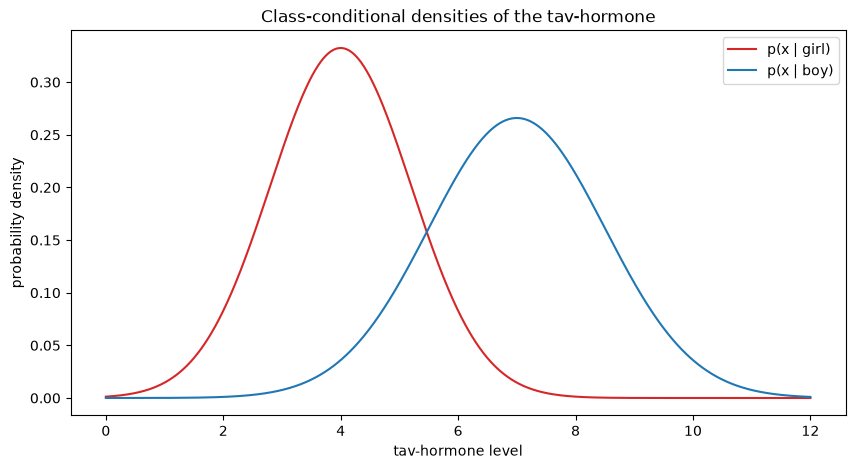

In [ ]:
# Priors (from the population / جامعه آماری)
P_GIRL, P_BOY = 0.7, 0.3

# Class-conditional distributions
girl_dist = stats.norm(loc=4.0, scale=1.2)
boy_dist  = stats.norm(loc=7.0, scale=1.5)

x = np.linspace(0, 12, 1000)

plt.plot(x, girl_dist.pdf(x), color="tab:red", label="p(x | girl)")
plt.plot(x, boy_dist.pdf(x),  color="tab:blue", label="p(x | boy)")
plt.xlabel("tav-hormone level")
plt.ylabel("probability density")
plt.title("Class-conditional densities of the tav-hormone")
plt.legend()
plt.show()

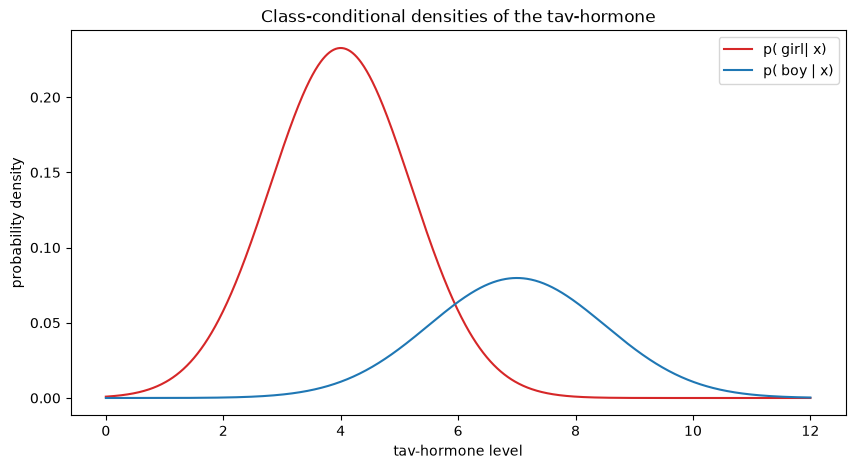

In [ ]:
plt.plot(x, girl_dist.pdf(x) * P_GIRL, color="tab:red", label="p( girl| x)")
plt.plot(x, boy_dist.pdf(x) * P_BOY,  color="tab:blue", label="p( boy | x)")
plt.xlabel("tav-hormone level")
plt.ylabel("probability density")
plt.title("Class-conditional densities of the tav-hormone")
plt.legend()
plt.show()

### ⚠️ Density is not probability!

A key concept: the y-axis above is **density**, not probability.
For a continuous variable, the probability of any *exact* value is zero:
$P(x = 5.000...) = 0$.

What density gives us is probability **per unit length**:

$$P(a \le x \le b) = \int_a^b p(x)\,dx$$

So a point with higher density means values *near* that point are more likely.
This is why comparing densities at a point is meaningful for making decisions.

In [ ]:
# Probability that a GIRL has hormone level between 3 and 5:
prob = girl_dist.cdf(5) - girl_dist.cdf(3)
print(f"P(3 <= x <= 5 | girl) = {prob:.3f}")

# The total area under each density curve is always 1:
from scipy.integrate import quad
area, _ = quad(girl_dist.pdf, -np.inf, np.inf)
print(f"Total area under p(x|girl) = {area:.3f}")

P(3 <= x <= 5 | girl) = 0.595
Total area under p(x|girl) = 1.000


## 👶 Sampling a population

Let's simulate 10,000 newborns from this country and look at the raw data.
This is what Mr. Tavasoli would actually *observe* — he never sees the true curves,
only samples!

In [ ]:
g_posterior = girl_dist.pdf(x) * P_GIRL
b_posterior = boy_dist.pdf(x) * P_BOY



In [ ]:
idx = np.where(g_posterior < b_posterior)[0][0]
x_star = x[idx]

In [ ]:
boy_samples

array([8.17777762, 4.33347856, 8.07211847, ..., 5.94202491, 7.74364836,
       7.96658268], shape=(3000,))

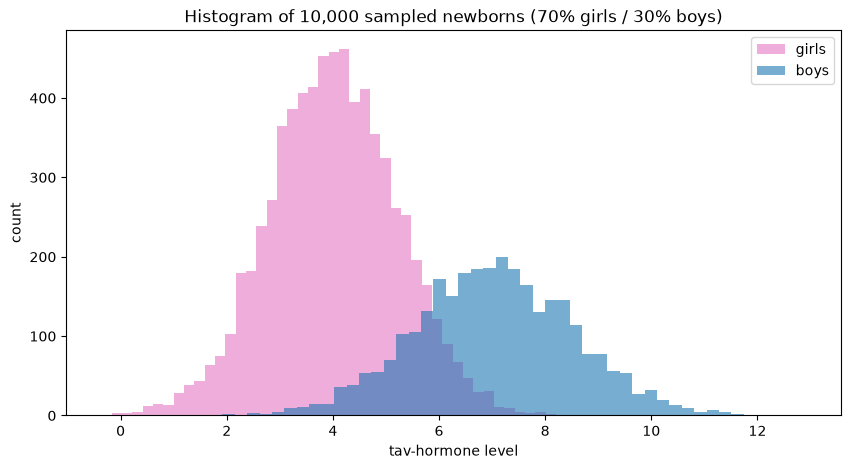

In [ ]:
n = 10_000
n_girls = int(n * P_GIRL)
n_boys  = n - n_girls

girl_samples = girl_dist.rvs(n_girls)
boy_samples  = boy_dist.rvs(n_boys)

plt.hist(girl_samples, bins=50, alpha=0.6, color="tab:pink", label="girls")
plt.hist(boy_samples,  bins=50, alpha=0.6, color="tab:blue", label="boys")
plt.xlabel("tav-hormone level")
plt.ylabel("count")
plt.title(f"Histogram of {n:,} sampled newborns (70% girls / 30% boys)")
plt.legend()
plt.show()

## 🎯 The optimal decision rule

Given a measurement $x$, Bayes' theorem tells us the **posterior** probability:

$$P(\text{girl} \mid x) = \frac{p(x \mid \text{girl})\,P(\text{girl})}{p(x)}$$

The best possible strategy (minimizing the probability of error) is to pick the class
with the **highest posterior**:


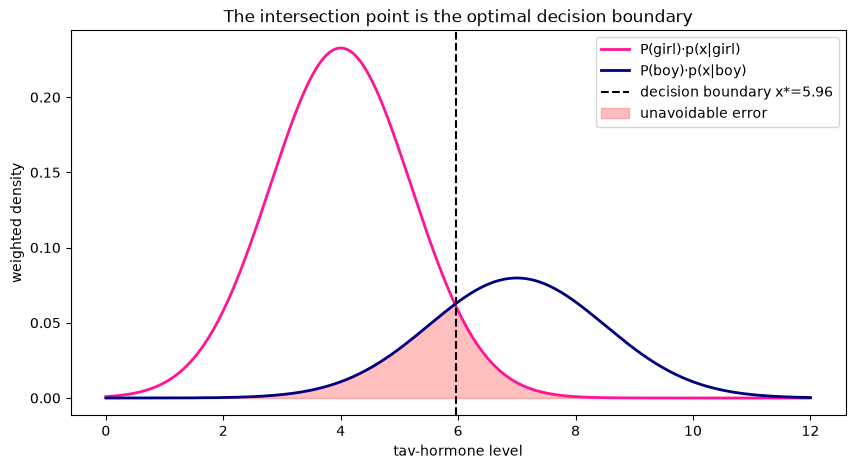

In [ ]:
g = girl_dist.pdf(x) * P_GIRL
b = boy_dist.pdf(x) * P_BOY

plt.plot(x, g, color="deeppink", lw=2, label="P(girl)·p(x|girl)")
plt.plot(x, b, color="navy", lw=2, label="P(boy)·p(x|boy)")
plt.axvline(x_star, color="k", ls="--", label=f"decision boundary x*={x_star:.2f}")

# Shade the error regions
plt.fill_between(x, np.minimum(g, b), color="red", alpha=0.25, label="unavoidable error")
plt.xlabel("tav-hormone level")
plt.ylabel("weighted density")
plt.title("The intersection point is the optimal decision boundary")
plt.legend()
plt.show()

The red area is the **Bayes error** — the minimum possible error rate for *any*
classifier. No algorithm, no matter how clever, can do better, because the classes
genuinely overlap.

Note how the boundary is **shifted toward the boys' side**: since girls are more
common (prior 0.7), we need stronger hormone evidence before predicting "boy".

In [ ]:
x_star = 6

In [ ]:
(girl_samples > 6).sum()

In [ ]:
# Verify empirically: classify our samples with the threshold
pred_boy_g = girl_samples > x_star   # girls misclassified as boys
pred_girl_b = boy_samples <= x_star  # boys misclassified as girls

error_rate = (pred_boy_g.sum() + pred_girl_b.sum()) / n
print(f"Empirical error rate with x* = {error_rate:.4f}")

# Compare with a naive threshold at the midpoint of the means (5.5)
naive = ((girl_samples > 5.5).sum() + (boy_samples <= 5.5).sum()) / n
print(f"Empirical error rate with naive threshold 5.5 = {naive:.4f}")

In [ ]:
((7.45 < girl_samples) & (girl_samples < 7.55)).sum()

np.int64(2)

In [ ]:
((7.45 < boy_samples) & (boy_samples < 7.55)).sum()

np.int64(71)